In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plots

In [2]:
rv_file = pd.read_csv('/output/ExampleEndurance/rv_moon_pa.csv', names = ['Time', 'x', 'y', 'z', 'vx', 'vy', 'vz'])
rover_file = pd.read_csv('/output/ExampleEndurance/rover_vec_pa.csv', names = ['Time', 'x', 'y', 'z', 'vx', 'vy', 'vz'])
pseudorange_file = pd.read_csv('/output/ExampleEndurance/z_pr.csv', names = ['Time', 'rho'])
pseudorange_rate_file = pd.read_csv('/output/ExampleEndurance/z_pr_rate.csv', names = ['Time', 'rho_rate'])
elevation_file = pd.read_csv('/output/ExampleEndurance/elevation.csv', names = ['Time', 'elev'])
# error_file = pd.read_csv('/output/ExampleEndurance/filter_error.csv', names = ['Time', 'error'])

## Pretty Plots

In [3]:
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
ax.scatter3D(rover_file['x'], rover_file['y'], rover_file['z'], color = 'tab:blue', label = 'Rover')
ax.plot3D(rv_file['x'], rv_file['y'], rv_file['z'], color = 'tab:orange', label = 'Lunar Pathfinder ELFO')

ax.view_init(elev = 25, azim = 130)
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.set_zlabel('z [km]')

for i, t in enumerate(elevation_file['Time']):
    y = np.rad2deg(elevation_file['elev'].iloc[i])
    if y>5:
        sat_pos = rv_file[rv_file["Time"] == t]
        rover_pos = rover_file[rover_file["Time"] == t]

        # print( [sat_pos["x"].iloc[0], rover_pos["x"].iloc[0]])

        ax.plot3D( [sat_pos["x"].iloc[0], rover_pos["x"].iloc[0]], 
                [sat_pos["y"].iloc[0], rover_pos["y"].iloc[0]],
                [sat_pos["z"].iloc[0], rover_pos["z"].iloc[0]],  color = 'tab:red',
                linewidth = 0.2)

r_moon = 1737.4; #km
image_file = '/analysis/moon_surface.jpeg'
img = plt.imread(image_file)
# define a grid matching the map size, subsample along with pixels
theta = np.linspace(0, np.pi, img.shape[0])[::-1]
phi = np.linspace(0, 2*np.pi, img.shape[1])[::-1]
count = 180 # keep 180 points along theta and phi
theta_inds = np.linspace(0, img.shape[0] - 1, count).round().astype(int)
phi_inds = np.linspace(0, img.shape[1] - 1, count).round().astype(int)
theta = theta[theta_inds]
phi = phi[phi_inds]
img = img[np.ix_(theta_inds, phi_inds)]
theta,phi = np.meshgrid(theta, phi)
R = r_moon
# sphere
x = R * np.sin(theta) * np.cos(phi)
y = R * np.sin(theta) * np.sin(phi)
z = R * np.cos(theta)
# create 3d Axes
ax.plot_surface(x.T, y.T, z.T, facecolors=img/255, cstride=1, rstride=1) # we've already pruned ourselves


u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:20j]
x = r_moon * np.cos(u) * np.sin(v)
y = r_moon * np.sin(u) * np.sin(v)
z = r_moon * np.cos(v)
ax.plot_surface(x, y, z, alpha = 1, color = 'grey')

ax.plot3D(np.nan, np.nan, np.nan, color = 'red', label = 'Transmission')
ax.axis('scaled')

plt.title('Moon-Fixed Moon-Centered Frame (PA)', size = 16)

plt.legend()
plt.show()


In [4]:
np.max(np.rad2deg(elevation_file['elev']))

55.17670766255792

(-90.0, 90.0)

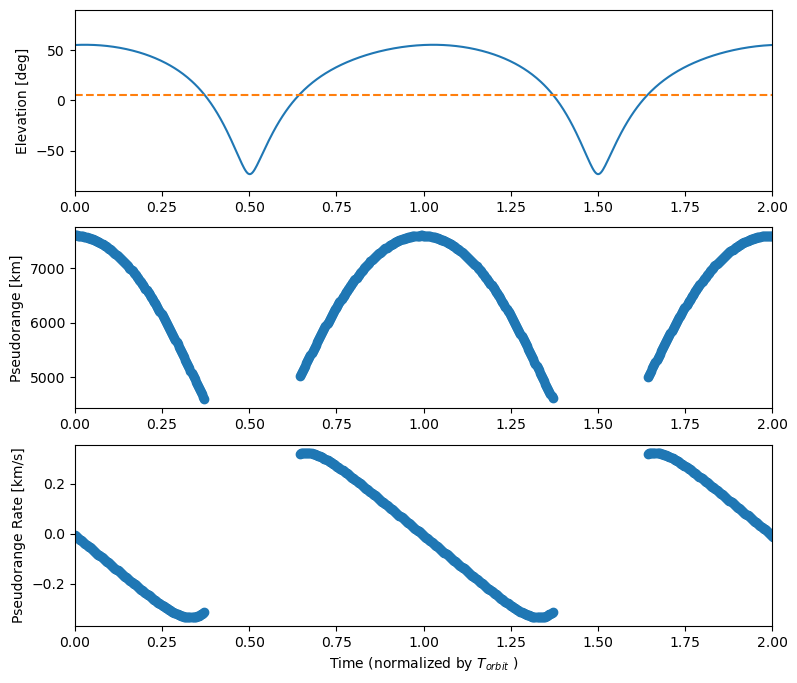

In [5]:
fig, axs = plt.subplots(3,1)
axs[0].plot( elevation_file['Time']/(3600*21.7/2), np.rad2deg(elevation_file['elev']) )
axs[0].plot( elevation_file['Time']/(3600*21.7/2), np.ones(len(elevation_file['Time']))*5, '--')
axs[0].set_ylabel('Elevation [deg]')
axs[1].scatter(pseudorange_file['Time']/(3600*21.7/2), pseudorange_file['rho'])
axs[1].set_ylabel('Pseudorange [km]')
axs[2].scatter(pseudorange_rate_file['Time']/(3600*21.7/2), pseudorange_rate_file['rho_rate'])
axs[2].set_ylabel('Pseudorange Rate [km/s]')
fig.set_size_inches(9,8)
plt.xlabel('Time (normalized by $T_{orbit}$ )')

axs[0].set_xlim(0,2);axs[1].set_xlim(0,2);axs[2].set_xlim(0,2)
axs[0].set_ylim(-90,90)


KeyError: -1

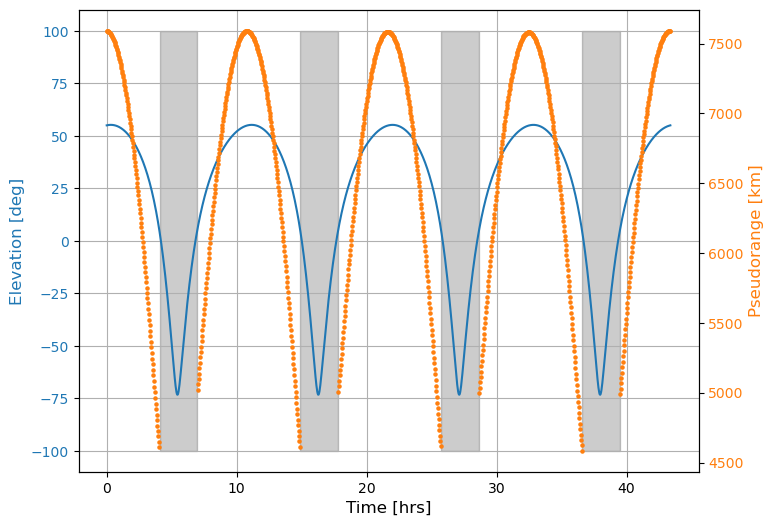

In [11]:
fig, ax1 = plt.subplots(figsize = (8,6))

y = np.rad2deg(elevation_file['elev'])

ax1.plot( elevation_file['Time']/(3600), y)
# ax1.plot( elevation_file['Time']/(3600*21.7/2), np.ones(len(elevation_file['Time']))*5, '--', color = 'black', label = 'Elevation Mask')

ax1.fill_between( elevation_file['Time']/(3600), -100, 100, where=(y<5), alpha = 0.2, color = 'black')

ax1.set_ylabel('Elevation [deg]', color = 'tab:blue', size = 12)
ax1.tick_params(axis="y", labelcolor='tab:blue')

ax2 = ax1.twinx()

ax2.scatter(pseudorange_file['Time']/(3600), pseudorange_file['rho'], color = 'tab:orange', s = 5)
ax2.set_ylabel('Pseudorange [km]', color = 'tab:orange', size = 12)
ax2.tick_params(axis="y", labelcolor='tab:orange')
ax1.set_xlabel('Time [hrs]', size = 12)
y_out = np.array([np.rad2deg(elevation_file['elev']) <5] )

# ax1.plot( elevation_file['Time']/(3600*21.7/2), np.rad2deg(elevation_file['elev']) )

# ax1.fill_between(x, y-y2, y+y2, alpha=0.2)

ax1.grid(); #ax1.legend();

ax1.set_xlim(0, pseudorange_file['Time'].iloc[-1]/(3600))
ax1.set_ylim(-90,90)

fig.set(dpi = 500)


In [14]:
pseudorange_file['Time'].iloc[-1]

156120

## Different locations plot

In [7]:
sp_elev = pd.read_csv('/output/SP_ExampleEndurance/elevation.csv', names = ['Time', 'elev'])
a_elev = pd.read_csv('/output/check_a_ExampleEndurance/elevation.csv', names = ['Time', 'elev'])
apollo_elev = pd.read_csv('/output/apollo_ExampleEndurance/elevation.csv', names = ['Time', 'elev'])


In [8]:
fig, ax1 = plt.subplots(figsize = (11,5))

y = np.rad2deg(sp_elev['elev'])
ax1.plot( sp_elev['Time']/(3600), y, label = 'South Pole')
ax1.set_ylabel('Elevation [deg]')
ax1.fill_between( sp_elev['Time']/(3600), -100, 100, where=(y<5), alpha = 0.1, color = 'blue')

y = np.rad2deg(a_elev['elev'])
ax1.plot( a_elev['Time']/(3600), y, label = 'Poincaré Q')
ax1.fill_between( a_elev['Time']/(3600), -100, 100, where=(y<5), alpha = 0.1, color = 'orange')

y = np.rad2deg(apollo_elev['elev'])
ax1.plot( apollo_elev['Time']/(3600), y, label = 'Apollo Peak Ring')
ax1.fill_between( apollo_elev['Time']/(3600), -100, 100, where=(y<5), alpha = 0.1, color = 'green')

ax1.set_xlabel('Time [hrs]')

ax1.grid(); ax1.legend();

ax1.set_xlim(0,21.7)
ax1.set_ylim(-90,90)

(-90.0, 90.0)